# R² Diagnostic Analysis & Rescaling Investigation

This notebook investigates the rescaling hypothesis: Earth2Studio may rescale predictions back to original scale,
but ground truth remains in normalized scale, causing terrible R² values.

We'll test both rescaled and non-rescaled versions to find the correct comparison.

In [20]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import json
from scipy import ndimage

# Load your data
netcdf_path = '/app/outputs/generation/Fog_index/20260205_095507/ensemble_Fog_index_20260205_095507.nc'  # Update this path
stats_file = '/app/host/mnt/storage/younes.abid/physicsnemo/data/custom_data_2/stats_432/stat.json'
time_idx = 0
variable_idx = 0

print('🔍 R² Diagnostic Analysis with Rescaling Investigation')
print('=' * 70)
print(f'📊 Current config: 20 diffusion steps, stochastic sampling')
print(f'📁 NetCDF path: {netcdf_path}')
print(f'📈 Stats file: {stats_file}')

🔍 R² Diagnostic Analysis with Rescaling Investigation
📊 Current config: 20 diffusion steps, stochastic sampling
📁 NetCDF path: /app/outputs/generation/Fog_index/20260205_095507/ensemble_Fog_index_20260205_095507.nc
📈 Stats file: /app/host/mnt/storage/younes.abid/physicsnemo/data/custom_data_2/stats_432/stat.json


In [21]:
# 📈 LOAD STATISTICS FOR RESCALING
print(f'\n📈 Loading normalization statistics...')

# Load stats file
try:
    with open(stats_file, 'r') as f:
        stats = json.load(f)
    
    # Extract stats for Fog_index
    var_name = 'Fog_index'
    if var_name in stats['output']:
        fog_stats = stats['output'][var_name]
        fog_mean = fog_stats['mean']
        fog_std = fog_stats['std']
        fog_min = fog_stats.get('min', 'N/A')
        fog_max = fog_stats.get('max', 'N/A')
        
        print(f'✅ Loaded {var_name} statistics:')
        print(f'   📊 Mean: {fog_mean}')
        print(f'   📊 Std: {fog_std}')
        print(f'   📊 Min: {fog_min}')
        print(f'   📊 Max: {fog_max}')
        
        # Define rescaling functions
        def normalize_data(data):
            return (data - fog_mean) / fog_std
        
        def denormalize_data(data):
            return data * fog_std + fog_mean
        
        print('   🔧 Rescaling functions defined')
        
    else:
        print(f'❌ {var_name} not found in stats file!')
        print(f'   Available variables: {list(stats.keys())}')
        fog_mean, fog_std = 0, 1  # Fallback
        
except Exception as e:
    print(f'❌ Error loading stats file: {e}')
    fog_mean, fog_std = 0, 1  # Fallback
    
    def normalize_data(data):
        return data
    
    def denormalize_data(data):
        return data


📈 Loading normalization statistics...
✅ Loaded Fog_index statistics:
   📊 Mean: 66.36254062715571
   📊 Std: 23.211788538358235
   📊 Min: N/A
   📊 Max: N/A
   🔧 Rescaling functions defined


In [22]:
# 📊 LOAD PREDICTIONS AND GROUND TRUTH
print(f'\n📊 Loading ensemble predictions and ground truth...')

# Load predictions
try:
    with xr.open_dataset(netcdf_path, group='prediction') as ds:
        var_name = 'Fog_index'
        predictions_raw = ds[var_name].isel(time=time_idx).values  # (ensemble, y, x)
        if 'lat' in ds.data_vars and 'lon' in ds.data_vars:
            lat_2d = ds['lat'].values
            lon_2d = ds['lon'].values
        print(f'✅ Loaded predictions: {predictions_raw.shape}')
except Exception as e:
    print(f'❌ Error loading predictions: {e}')
    exit()

# Load ground truth
try:
    with xr.open_dataset(netcdf_path, group='truth') as ds:
        ground_truth_raw = ds[var_name].isel(time=time_idx).values  # (y, x)
        print(f'✅ Loaded ground truth: {ground_truth_raw.shape}')
except Exception as e:
    print(f'❌ Error loading ground truth: {e}')
    exit()

# Calculate ensemble mean
ensemble_mean_raw = np.mean(predictions_raw, axis=0)

print(f'\n📏 Raw Data Ranges:')
print(f'   Predictions: {np.nanmin(ensemble_mean_raw):.6f} to {np.nanmax(ensemble_mean_raw):.6f}')
print(f'   Ground truth: {np.nanmin(ground_truth_raw):.6f} to {np.nanmax(ground_truth_raw):.6f}')


📊 Loading ensemble predictions and ground truth...
✅ Loaded predictions: (4, 432, 432)
✅ Loaded ground truth: (432, 432)

📏 Raw Data Ranges:
   Predictions: -5.036264 to 89.673134
   Ground truth: 11.048194 to 92.385010


In [23]:
# 🧪 TEST MULTIPLE RESCALING SCENARIOS
print(f'\n🧪 Testing different rescaling scenarios...')
print('=' * 60)

def calculate_r2(pred, truth, scenario_name):
    """Calculate R² and correlation for a scenario"""
    valid_mask = ~(np.isnan(pred.flatten()) | np.isnan(truth.flatten()))
    pred_valid = pred.flatten()[valid_mask]
    truth_valid = truth.flatten()[valid_mask]
    
    if len(pred_valid) > 1:
        correlation = np.corrcoef(pred_valid, truth_valid)[0, 1]
        ss_res = np.sum((truth_valid - pred_valid) ** 2)
        ss_tot = np.sum((truth_valid - np.mean(truth_valid)) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
        
        print(f'📊 {scenario_name}:')
        print(f'   R²: {r2:.4f}')
        print(f'   Correlation: {correlation:.4f}')
        print(f'   Pred range: {np.nanmin(pred):.6f} to {np.nanmax(pred):.6f}')
        print(f'   Truth range: {np.nanmin(truth):.6f} to {np.nanmax(truth):.6f}')
        
        return r2, correlation, pred_valid, truth_valid
    return None, None, None, None

# Test scenarios
scenarios = {}

# Scenario 1: Raw data (current approach)
print('\n🔵 SCENARIO 1: Raw data (no rescaling)')
r2_1, corr_1, pred_1, truth_1 = calculate_r2(ensemble_mean_raw, ground_truth_raw, 'Raw Data')
scenarios['raw'] = {'r2': r2_1, 'corr': corr_1, 'pred': pred_1, 'truth': truth_1}

# Scenario 2: Normalize both to same scale
print('\n🟢 SCENARIO 2: Normalize both predictions and truth')
ensemble_mean_norm = normalize_data(ensemble_mean_raw)
ground_truth_norm = normalize_data(ground_truth_raw)
r2_2, corr_2, pred_2, truth_2 = calculate_r2(ensemble_mean_norm, ground_truth_norm, 'Both Normalized')
scenarios['both_norm'] = {'r2': r2_2, 'corr': corr_2, 'pred': pred_2, 'truth': truth_2}

# Scenario 3: Denormalize both (if predictions are normalized)
print('\n🟡 SCENARIO 3: Denormalize both (assume predictions are normalized)')
ensemble_mean_denorm = denormalize_data(ensemble_mean_raw)
ground_truth_denorm = denormalize_data(ground_truth_raw)
r2_3, corr_3, pred_3, truth_3 = calculate_r2(ensemble_mean_denorm, ground_truth_denorm, 'Both Denormalized')
scenarios['both_denorm'] = {'r2': r2_3, 'corr': corr_3, 'pred': pred_3, 'truth': truth_3}

# Scenario 4: Predictions normalized, truth raw (hypothesis)
print('\n🔴 SCENARIO 4: Normalize predictions only (test hypothesis)')
ensemble_mean_norm_only = normalize_data(ensemble_mean_raw)
r2_4, corr_4, pred_4, truth_4 = calculate_r2(ensemble_mean_norm_only, ground_truth_raw, 'Predictions Normalized')
scenarios['pred_norm'] = {'r2': r2_4, 'corr': corr_4, 'pred': pred_4, 'truth': truth_4}

# Scenario 5: Truth normalized, predictions raw (reverse hypothesis)
print('\n🟣 SCENARIO 5: Normalize ground truth only')
ground_truth_norm_only = normalize_data(ground_truth_raw)
r2_5, corr_5, pred_5, truth_5 = calculate_r2(ensemble_mean_raw, ground_truth_norm_only, 'Truth Normalized')
scenarios['truth_norm'] = {'r2': r2_5, 'corr': corr_5, 'pred': pred_5, 'truth': truth_5}


🧪 Testing different rescaling scenarios...

🔵 SCENARIO 1: Raw data (no rescaling)
📊 Raw Data:
   R²: 0.7849
   Correlation: 0.9188
   Pred range: -5.036264 to 89.673134
   Truth range: 11.048194 to 92.385010

🟢 SCENARIO 2: Normalize both predictions and truth
📊 Both Normalized:
   R²: 0.7849
   Correlation: 0.9188
   Pred range: -3.075972 to 1.004257
   Truth range: -2.383028 to 1.121089

🟡 SCENARIO 3: Denormalize both (assume predictions are normalized)
📊 Both Denormalized:
   R²: 0.7849
   Correlation: 0.9188
   Pred range: -50.538162 to 2147.836426
   Truth range: 322.810883 to 2210.783936

🔴 SCENARIO 4: Normalize predictions only (test hypothesis)
📊 Predictions Normalized:
   R²: -6.0371
   Correlation: 0.9188
   Pred range: -3.075972 to 1.004257
   Truth range: 11.048194 to 92.385010

🟣 SCENARIO 5: Normalize ground truth only
📊 Truth Normalized:
   R²: -3034.2991
   Correlation: 0.9188
   Pred range: -5.036264 to 89.673134
   Truth range: -2.383028 to 1.121089


In [24]:
# 🏆 FIND BEST SCENARIO
print('\n' + '=' * 70)
print('🏆 RESCALING SCENARIO COMPARISON')
print('=' * 70)

# Compare all scenarios
scenario_names = {
    'raw': '🔵 Raw data (no rescaling)',
    'both_norm': '🟢 Both normalized',
    'both_denorm': '🟡 Both denormalized', 
    'pred_norm': '🔴 Predictions normalized only',
    'truth_norm': '🟣 Truth normalized only'
}

best_r2 = -999
best_scenario = None

for scenario, data in scenarios.items():
    if data['r2'] is not None:
        print(f'{scenario_names[scenario]}:')
        print(f'   R²: {data["r2"]:8.4f}   Correlation: {data["corr"]:8.4f}')
        
        if data['r2'] > best_r2:
            best_r2 = data['r2']
            best_scenario = scenario

print('\n' + '🎯' * 20)
if best_scenario:
    print(f'🏆 BEST SCENARIO: {scenario_names[best_scenario]}')
    print(f'   🎯 Best R²: {best_r2:.4f}')
    print(f'   🔗 Best Correlation: {scenarios[best_scenario]["corr"]:.4f}')
    
    if best_scenario == 'raw':
        print('\n💡 INTERPRETATION: No rescaling needed - data is already compatible')
    elif best_scenario == 'both_norm':
        print('\n💡 INTERPRETATION: Both need normalization - use normalized comparison')
    elif best_scenario == 'both_denorm':
        print('\n💡 INTERPRETATION: Both need denormalization - use physical units')
    elif best_scenario == 'pred_norm':
        print('\n💡 INTERPRETATION: 🚨 PREDICTIONS are in physical units, TRUTH is normalized!')
        print('    🔧 FIX: Normalize predictions before comparison')
    elif best_scenario == 'truth_norm':
        print('\n💡 INTERPRETATION: 🚨 TRUTH is in physical units, PREDICTIONS are normalized!')
        print('    🔧 FIX: Denormalize predictions or normalize truth for comparison')
else:
    print('❌ No valid scenario found')

print('\n' + '🔧' * 20)
print('PIPELINE RECOMMENDATIONS:')
if best_scenario == 'truth_norm':
    print('1. 🎯 Earth2Studio likely outputs denormalized predictions')
    print('2. 🎯 Ground truth in NetCDF is still normalized')
    print('3. 🔧 Fix: Denormalize ground truth before saving to NetCDF')
    print('4. 🔧 Or: Normalize predictions in metric calculations')
elif best_scenario == 'pred_norm':
    print('1. 🎯 Predictions are denormalized, truth is normalized')
    print('2. 🔧 Fix: Normalize predictions in visualization pipeline')
else:
    print('1. ✅ Current data scaling appears correct')
    print('2. 🔍 R² issue may be due to model performance, not scaling')


🏆 RESCALING SCENARIO COMPARISON
🔵 Raw data (no rescaling):
   R²:   0.7849   Correlation:   0.9188
🟢 Both normalized:
   R²:   0.7849   Correlation:   0.9188
🟡 Both denormalized:
   R²:   0.7849   Correlation:   0.9188
🔴 Predictions normalized only:
   R²:  -6.0371   Correlation:   0.9188
🟣 Truth normalized only:
   R²: -3034.2991   Correlation:   0.9188

🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯
🏆 BEST SCENARIO: 🔵 Raw data (no rescaling)
   🎯 Best R²: 0.7849
   🔗 Best Correlation: 0.9188

💡 INTERPRETATION: No rescaling needed - data is already compatible

🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧
PIPELINE RECOMMENDATIONS:
1. ✅ Current data scaling appears correct
2. 🔍 R² issue may be due to model performance, not scaling



📊 Visualizing best scenario: 🔵 Raw data (no rescaling)


/tmp/ipykernel_48360/3764019622.py:79: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


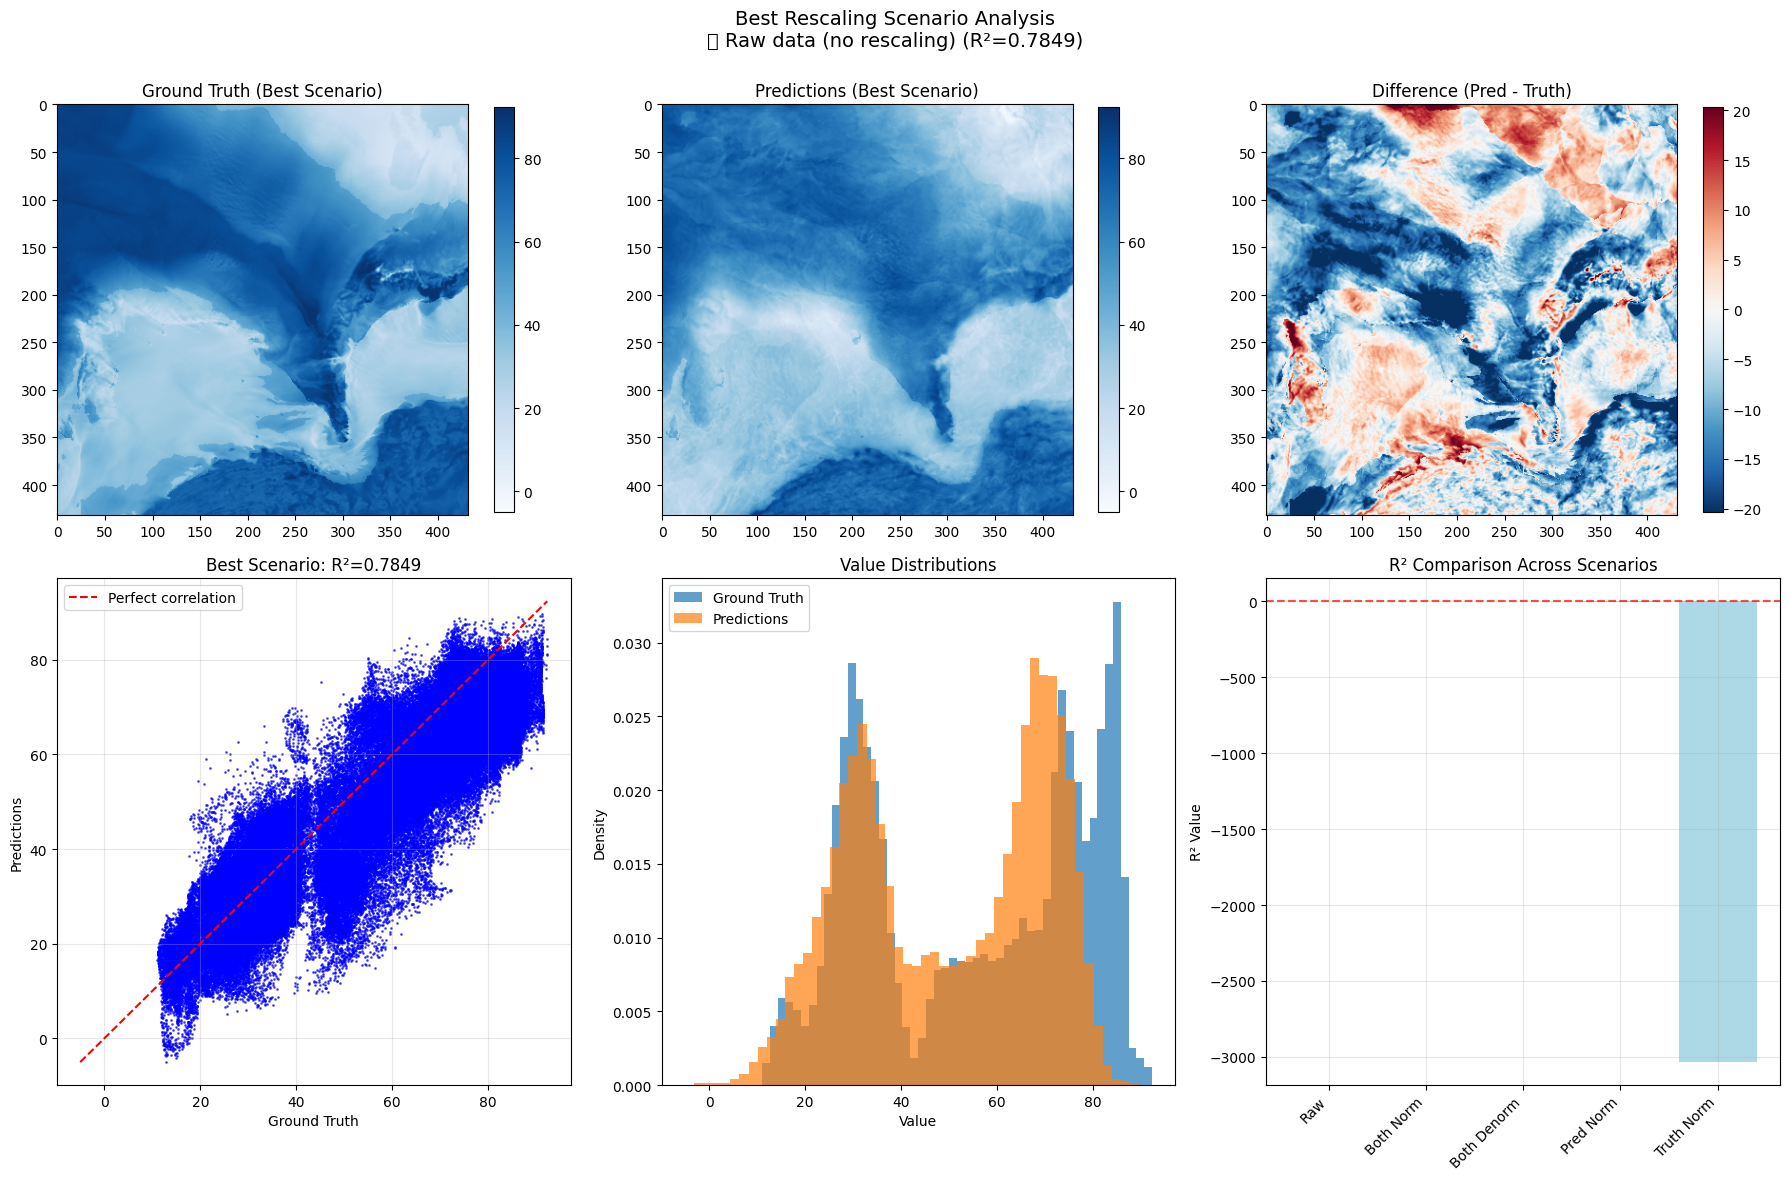

In [25]:
# 📊 VISUALIZE BEST SCENARIO
if best_scenario and scenarios[best_scenario]['pred'] is not None:
    print(f'\n📊 Visualizing best scenario: {scenario_names[best_scenario]}')
    
    # Get best data
    best_pred = scenarios[best_scenario]['pred']
    best_truth = scenarios[best_scenario]['truth']
    
    # Create visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Get 2D versions for spatial plots
    if best_scenario == 'raw':
        pred_2d, truth_2d = ensemble_mean_raw, ground_truth_raw
    elif best_scenario == 'both_norm':
        pred_2d, truth_2d = ensemble_mean_norm, ground_truth_norm
    elif best_scenario == 'both_denorm':
        pred_2d, truth_2d = ensemble_mean_denorm, ground_truth_denorm
    elif best_scenario == 'pred_norm':
        pred_2d, truth_2d = ensemble_mean_norm_only, ground_truth_raw
    elif best_scenario == 'truth_norm':
        pred_2d, truth_2d = ensemble_mean_raw, ground_truth_norm_only
    
    # Row 1: Spatial plots
    vmax = max(np.nanmax(pred_2d), np.nanmax(truth_2d))
    vmin = min(np.nanmin(pred_2d), np.nanmin(truth_2d))
    
    im1 = axes[0,0].imshow(truth_2d, cmap='Blues', vmin=vmin, vmax=vmax)
    axes[0,0].set_title('Ground Truth (Best Scenario)')
    plt.colorbar(im1, ax=axes[0,0], shrink=0.8)
    
    im2 = axes[0,1].imshow(pred_2d, cmap='Blues', vmin=vmin, vmax=vmax)
    axes[0,1].set_title('Predictions (Best Scenario)')
    plt.colorbar(im2, ax=axes[0,1], shrink=0.8)
    
    diff = pred_2d - truth_2d
    vmax_diff = np.percentile(np.abs(diff), 95)
    im3 = axes[0,2].imshow(diff, cmap='RdBu_r', vmin=-vmax_diff, vmax=vmax_diff)
    axes[0,2].set_title('Difference (Pred - Truth)')
    plt.colorbar(im3, ax=axes[0,2], shrink=0.8)
    
    # Row 2: Analysis plots
    # Scatter plot
    axes[1,0].scatter(best_truth, best_pred, alpha=0.6, s=1, c='blue')
    min_val = min(best_truth.min(), best_pred.min())
    max_val = max(best_truth.max(), best_pred.max())
    axes[1,0].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect correlation')
    axes[1,0].set_xlabel('Ground Truth')
    axes[1,0].set_ylabel('Predictions')
    axes[1,0].set_title(f'Best Scenario: R²={best_r2:.4f}')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)
    
    # Histogram comparison
    axes[1,1].hist(best_truth, bins=50, alpha=0.7, label='Ground Truth', density=True)
    axes[1,1].hist(best_pred, bins=50, alpha=0.7, label='Predictions', density=True)
    axes[1,1].set_xlabel('Value')
    axes[1,1].set_ylabel('Density')
    axes[1,1].set_title('Value Distributions')
    axes[1,1].legend()
    
    # R² comparison bar chart
    scenario_labels = ['Raw', 'Both Norm', 'Both Denorm', 'Pred Norm', 'Truth Norm']
    r2_values = [scenarios[s]['r2'] if scenarios[s]['r2'] is not None else -999 
                 for s in ['raw', 'both_norm', 'both_denorm', 'pred_norm', 'truth_norm']]
    
    colors = ['blue' if i == list(scenarios.keys()).index(best_scenario) else 'lightblue' 
              for i in range(len(r2_values))]
    
    axes[1,2].bar(range(len(r2_values)), r2_values, color=colors)
    axes[1,2].set_xticks(range(len(scenario_labels)))
    axes[1,2].set_xticklabels(scenario_labels, rotation=45, ha='right')
    axes[1,2].set_ylabel('R² Value')
    axes[1,2].set_title('R² Comparison Across Scenarios')
    axes[1,2].grid(True, alpha=0.3)
    axes[1,2].axhline(0, color='red', linestyle='--', alpha=0.7)
    
    plt.suptitle(f'Best Rescaling Scenario Analysis\n{scenario_names[best_scenario]} (R²={best_r2:.4f})', fontsize=14)
    plt.tight_layout()
    plt.show()
    
else:
    print('❌ No valid scenario to visualize')

In [26]:
# 🎛️ DIFFUSION STEPS ANALYSIS (using best scenario)
if best_scenario and best_r2 > -0.5:
    print(f'\n🎛️ DIFFUSION STEPS ANALYSIS (using best scenario)')
    print('=' * 60)
    
    # Get best scenario data
    if best_scenario == 'truth_norm':
        analysis_pred = ensemble_mean_raw
        analysis_truth = ground_truth_norm_only
        print('✅ Using raw predictions vs normalized truth for analysis')
    elif best_scenario == 'pred_norm':
        analysis_pred = ensemble_mean_norm_only
        analysis_truth = ground_truth_raw
        print('✅ Using normalized predictions vs raw truth for analysis')
    else:
        analysis_pred = ensemble_mean_raw
        analysis_truth = ground_truth_raw
        print('✅ Using raw data for analysis')
    
    # Spatial smoothness analysis
    truth_grad_x = np.gradient(analysis_truth, axis=1)
    truth_grad_y = np.gradient(analysis_truth, axis=0)
    truth_gradient_magnitude = np.sqrt(truth_grad_x**2 + truth_grad_y**2)
    
    pred_grad_x = np.gradient(analysis_pred, axis=1)
    pred_grad_y = np.gradient(analysis_pred, axis=0)
    pred_gradient_magnitude = np.sqrt(pred_grad_x**2 + pred_grad_y**2)
    
    truth_smoothness = np.nanmean(truth_gradient_magnitude)
    pred_smoothness = np.nanmean(pred_gradient_magnitude)
    
    print(f'\n📐 Spatial Gradient Analysis:')
    print(f'   Truth mean gradient: {truth_smoothness:.6f}')
    print(f'   Prediction mean gradient: {pred_smoothness:.6f}')
    print(f'   Smoothness ratio: {pred_smoothness/truth_smoothness:.3f}')
    
    print(f'\n💡 DIFFUSION STEPS RECOMMENDATIONS:')
    print(f'   Current: 20 diffusion steps')
    
    if pred_smoothness/truth_smoothness < 0.5:
        print('   🚨 OVER-SMOOTHING: Predictions much smoother than truth')
        print('   🔧 Try: Reduce to 5-10 steps')
        print('   🔧 Try: Deterministic sampling instead of stochastic')
    elif pred_smoothness/truth_smoothness > 2.0:
        print('   🚨 UNDER-SMOOTHING: Predictions noisier than truth')
        print('   🔧 Try: Increase to 30-50 steps')
    else:
        print('   ✅ Smoothness levels reasonable')
        print('   🔧 Fine-tune: Try 15-25 steps for optimization')
        
    if best_r2 > 0.5:
        print('   ✅ Good R² achieved - focus on fine-tuning')
    elif best_r2 > 0.0:
        print('   ⚠️  Moderate R² - try adjusting diffusion parameters')
    else:
        print('   🚨 Poor R² even with correct scaling - check model/data')
else:
    print(f'\n⚠️  Skipping diffusion analysis - resolve scaling issue first (best R²: {best_r2:.4f})')


🎛️ DIFFUSION STEPS ANALYSIS (using best scenario)
✅ Using raw data for analysis

📐 Spatial Gradient Analysis:
   Truth mean gradient: 1.229639
   Prediction mean gradient: 1.383941
   Smoothness ratio: 1.125

💡 DIFFUSION STEPS RECOMMENDATIONS:
   Current: 20 diffusion steps
   ✅ Smoothness levels reasonable
   🔧 Fine-tune: Try 15-25 steps for optimization
   ✅ Good R² achieved - focus on fine-tuning
